# Oracc Metadata Exploratory Data Analysis
This notebook analyzes the `oracc_unique.jsonl` dataset to explore the completeness and distribution of metadata fields.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

dataset_path = r'C:\Programming\akkadian\data\oracc_dataset\oracc_unique.jsonl'

print('Loading data...')
records = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'Total rows: {len(df)}')

meta_cols = [c for c in df.columns if c not in ['raw', 'signs']]

Loading data...
Total rows: 404194


## 1. Non-Null Counts
Calculating how many non-null/non-unknown values exist for each metadata column.

In [2]:
print('--- NON-NULL COUNTS ---')
for col in meta_cols:
    # Treat 'unknown' as null for accurate counting
    temp_col = df[col].replace('unknown', pd.NA)
    non_null_count = temp_col.notna().sum()
    print(f"{col}: {non_null_count} / {len(df)} ({(non_null_count/len(df))*100:.1f}%)")

--- NON-NULL COUNTS ---
period: 400035 / 404194 (99.0%)
genre: 304585 / 404194 (75.4%)
provenience: 386389 / 404194 (95.6%)
language: 289665 / 404194 (71.7%)
dialect: 42266 / 404194 (10.5%)
material: 280889 / 404194 (69.5%)
object_type: 332632 / 404194 (82.3%)
script: 166930 / 404194 (41.3%)
ruler: 176951 / 404194 (43.8%)


## 2. Distributions and Top 10
Showing the top 10 values for each column and plotting the full distribution of all categories.


Top 10 values for period:
period
Neo-Assyrian         196643
Old Babylonian        61762
Middle Assyrian       43163
Middle Babylonian     37400
Neo-Babylonian        22527
Seleucid               4438
Achaemenid             4108
ED IIIa                4080
unknown                3504
First Millennium       3132
Name: count, dtype: int64




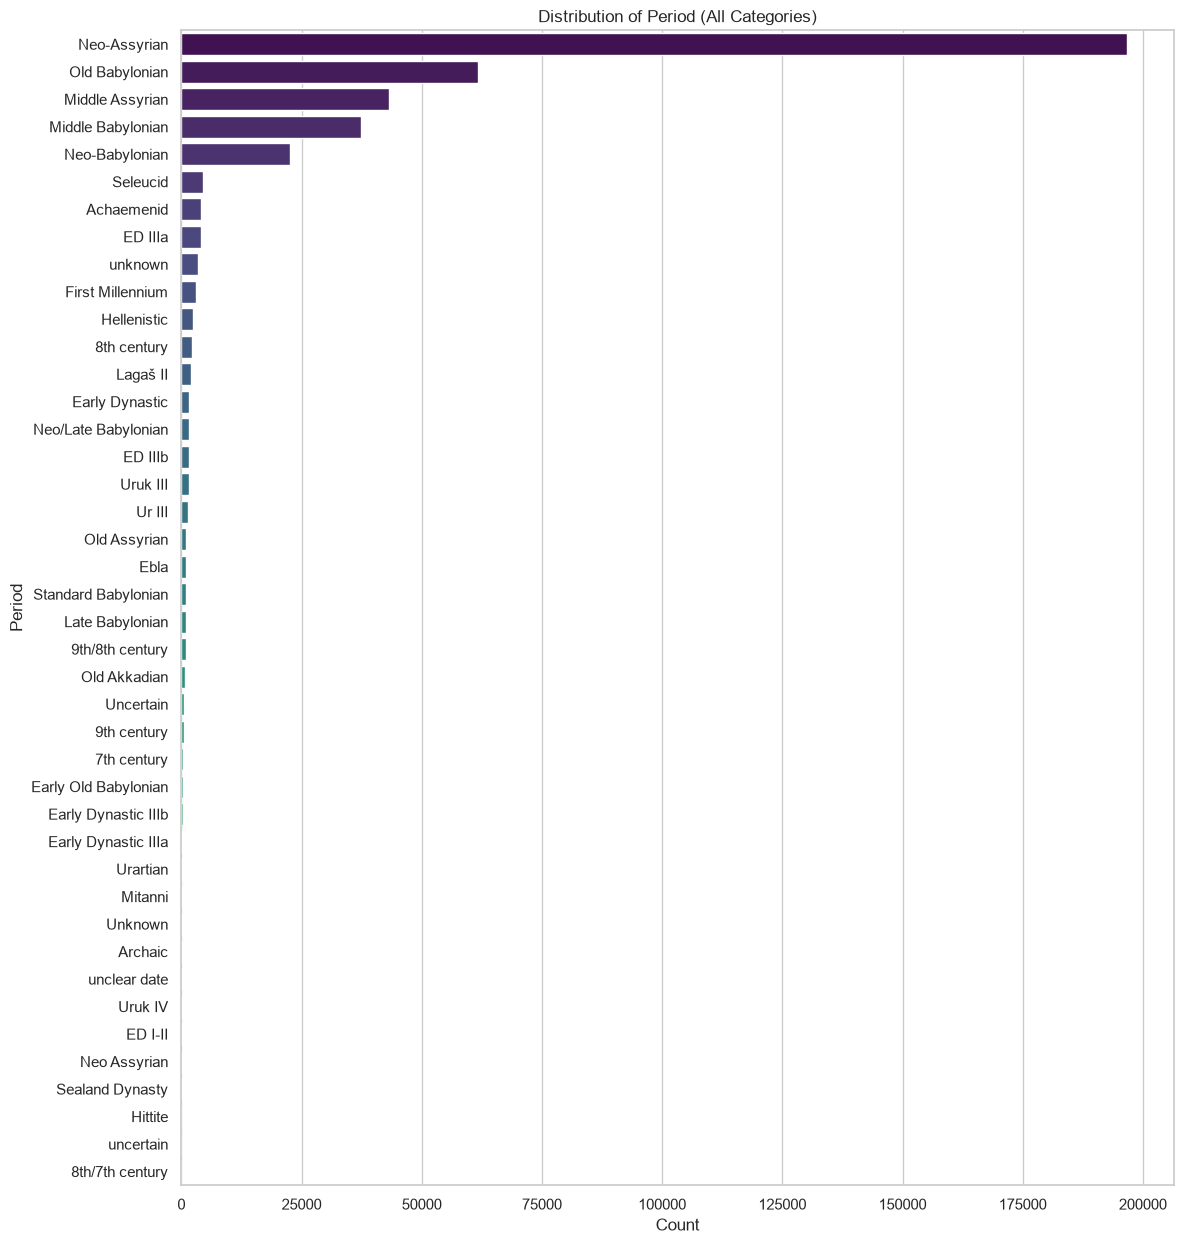


Top 10 values for genre:
genre
unknown                  98954
Royal Inscription        85778
Lexical                  70915
Administrative Letter    33314
Literary                 15810
lexical                  15433
Legal Transaction        11711
letter                    8468
Administrative Record     7339
Scholarly Letter          7029
Name: count, dtype: int64




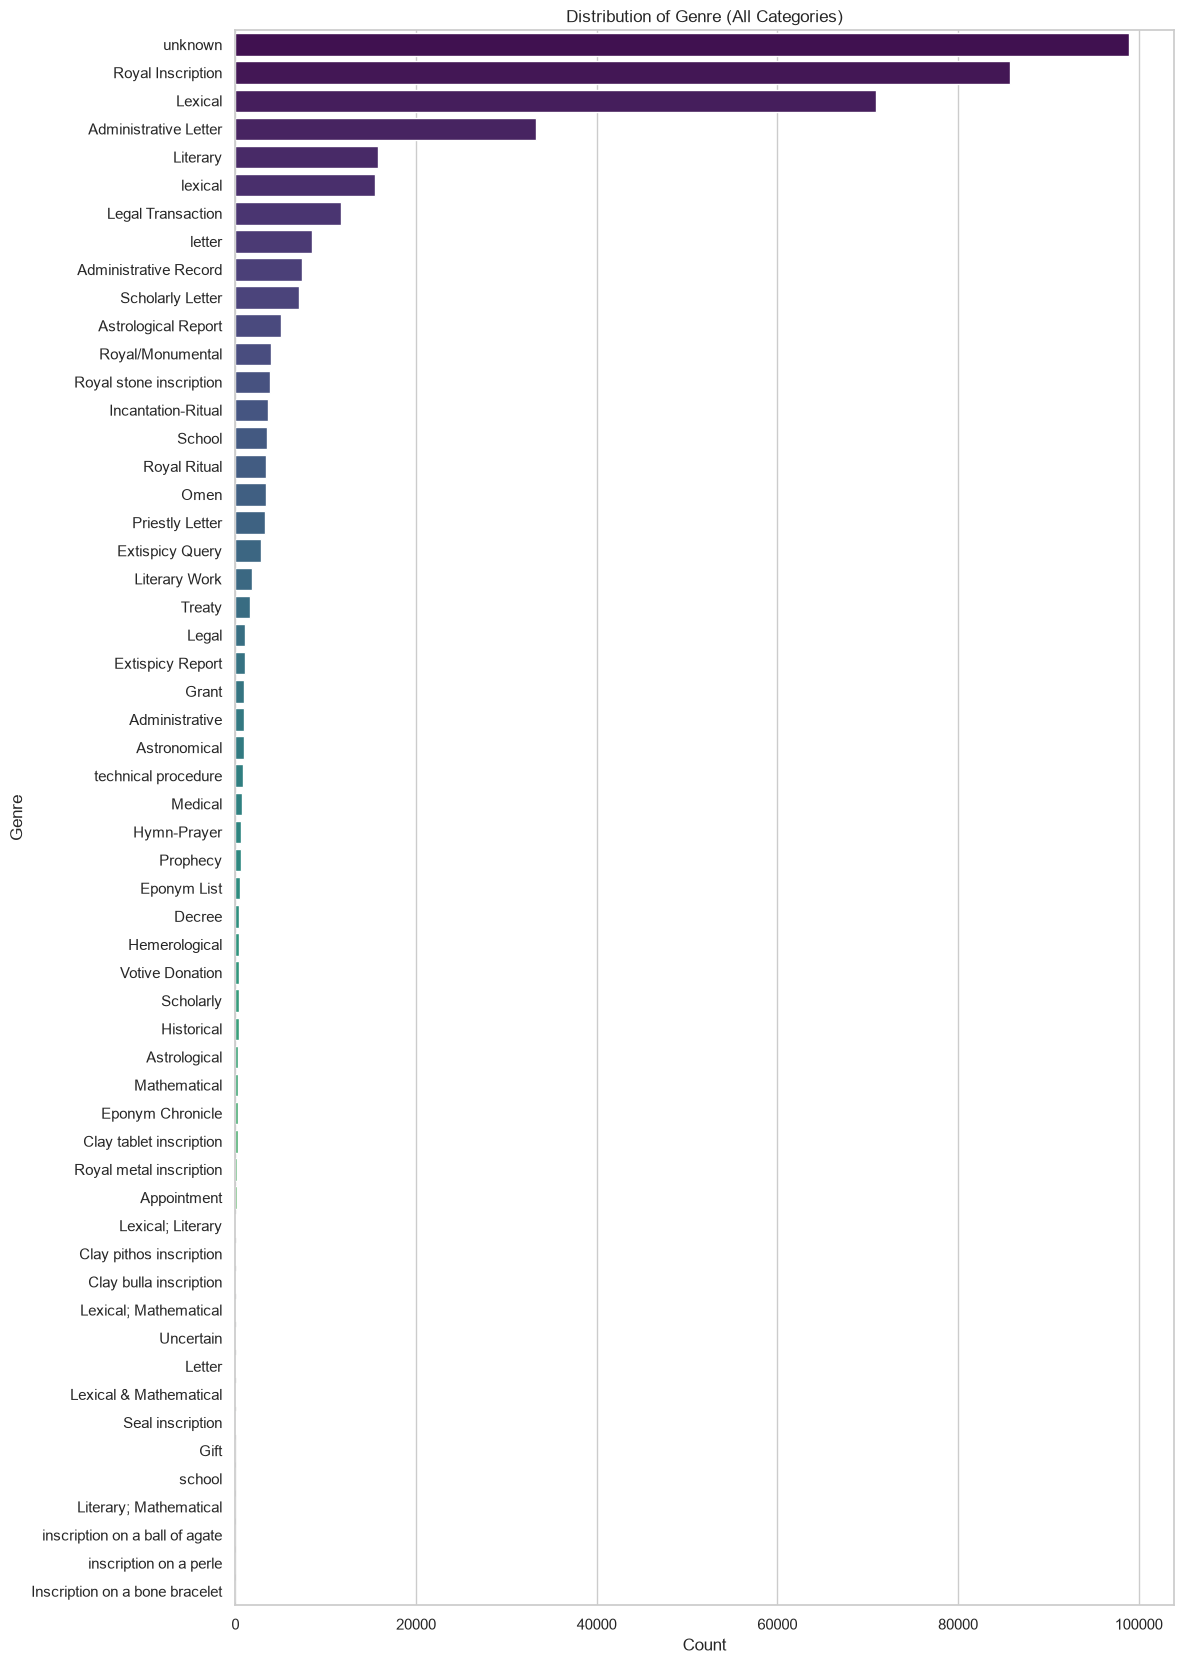


Top 10 values for provenience:
provenience
Kuyunjik (Nineveh)             90595
Nineveh                        55143
Nippur                         30978
unclear                        19826
Aššur (mod. Qalʿat Sherqat)    18185
unknown                        17150
Uruk                           13961
Ugarit (mod. Ras Shamra)       13718
Assur                          13531
Sippar                         10974
Name: count, dtype: int64







Top 10 values for language:
language
Akkadian                       199633
unknown                        113874
Sumerian                        45070
Middle Assyrian                 28756
Urartian                         4248
Sumerian; Akkadian               3745
Hittite                          1842
undetermined                     1546
Sumerian/Akkadian Bilingual       987
bilingual                         785
Name: count, dtype: int64




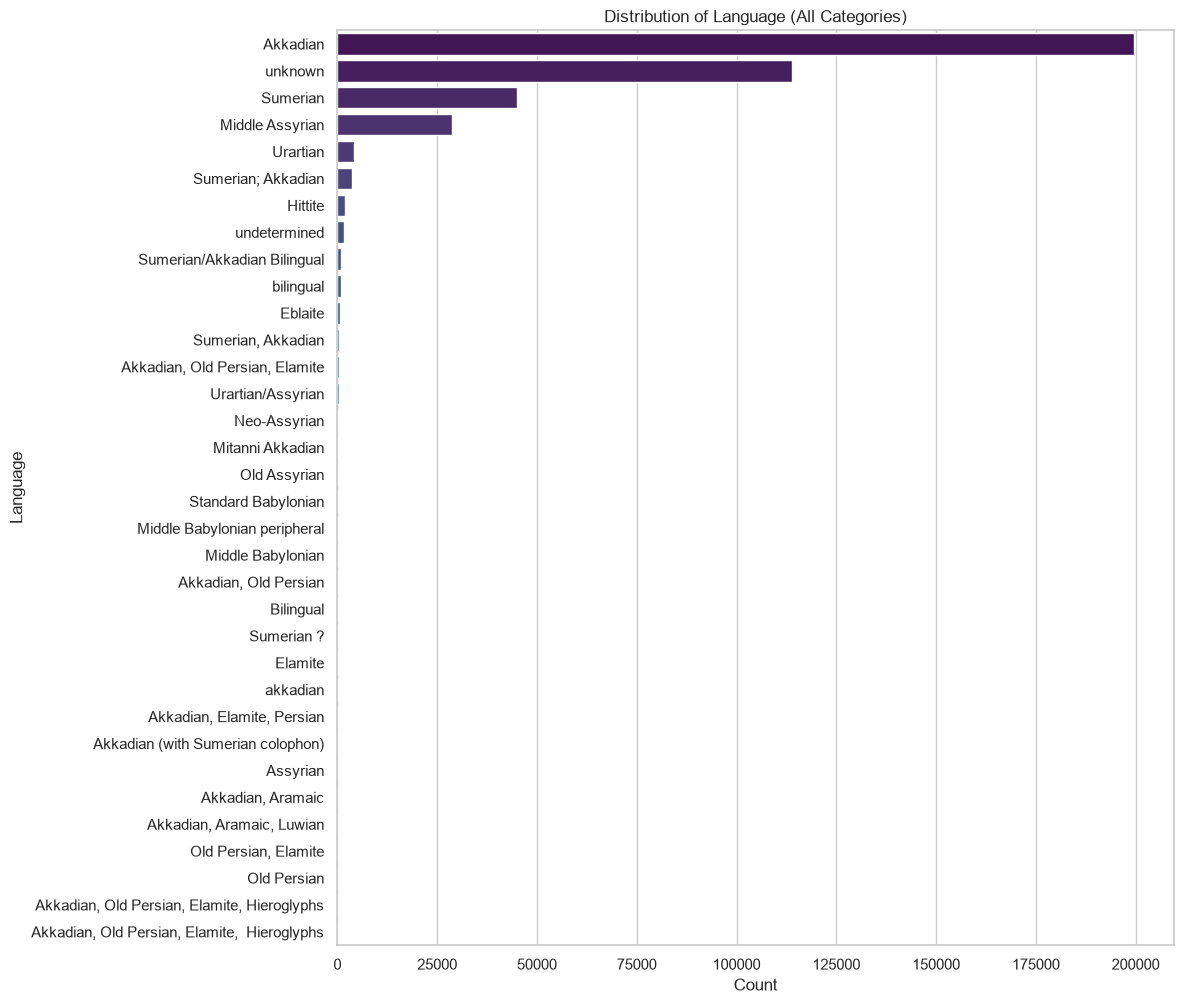


Top 10 values for dialect:
dialect
unknown                361273
Neo-Assyrian            24753
Neo-Babylonian          17493
Standard Babylonian        20
Name: count, dtype: int64




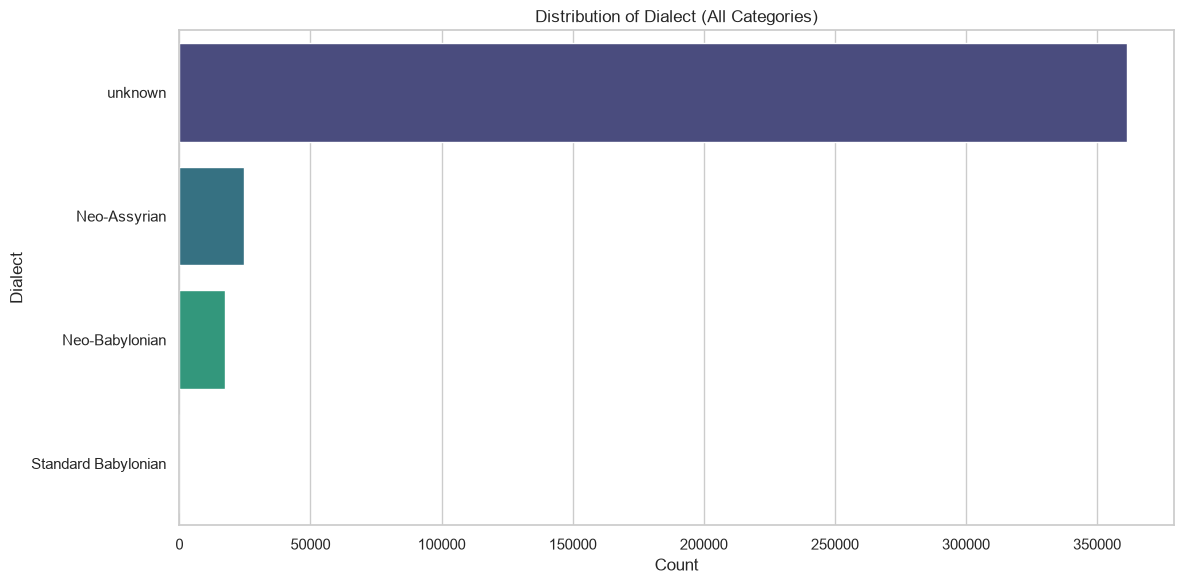


Top 10 values for material:
material
clay                255882
unknown             122650
stone                20147
clay, stone            864
stone: diorite         609
rock                   597
stone: limestone       498
metal                  350
caly                   249
bronze                 157
Name: count, dtype: int64




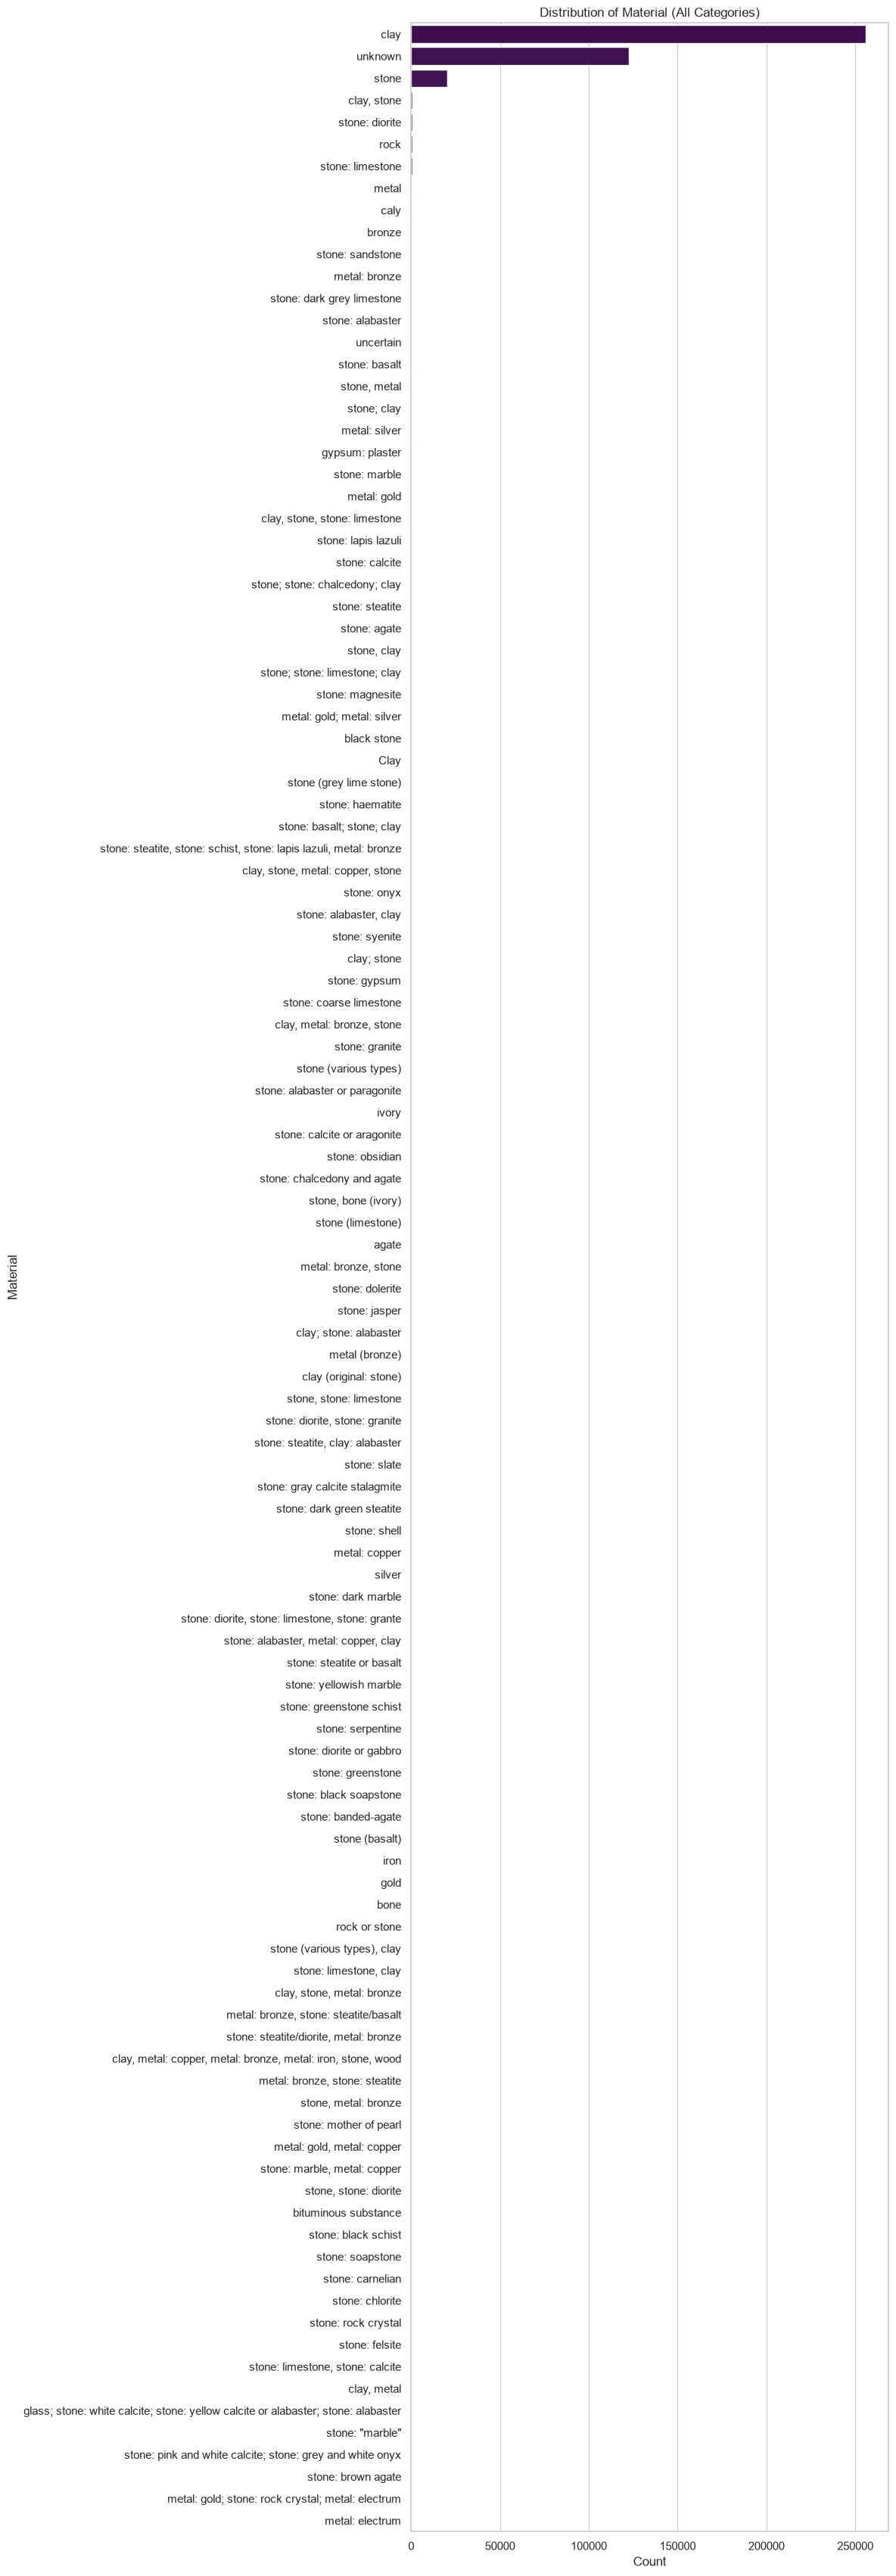


Top 10 values for object_type:
object_type
tablet                      235403
unknown                      70907
prism                        40228
cylinder                     15810
Single-column tablet          5726
Two-column tablet             5686
stele                         5249
brick                         1794
wall slab (with reliefs)      1708
slab                          1447
Name: count, dtype: int64




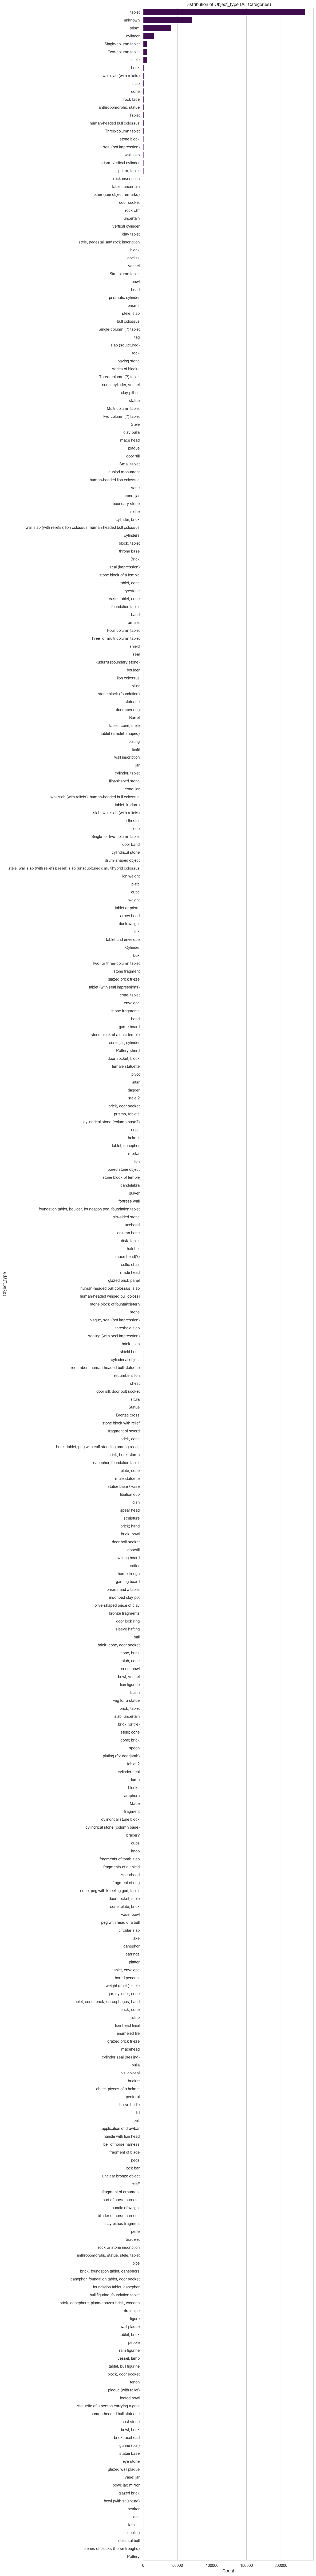


Top 10 values for script:
script
unknown                       236609
Neo-Assyrian                  124900
Neo-Babylonian                 24693
Middle Assyrian                 5075
Urartian                        4533
Neo/Late Babylonian             2690
Old Assyrian                     846
Archaizing  Neo-Babylonian       678
Old Persian                      659
Late Babylonian                  587
Name: count, dtype: int64




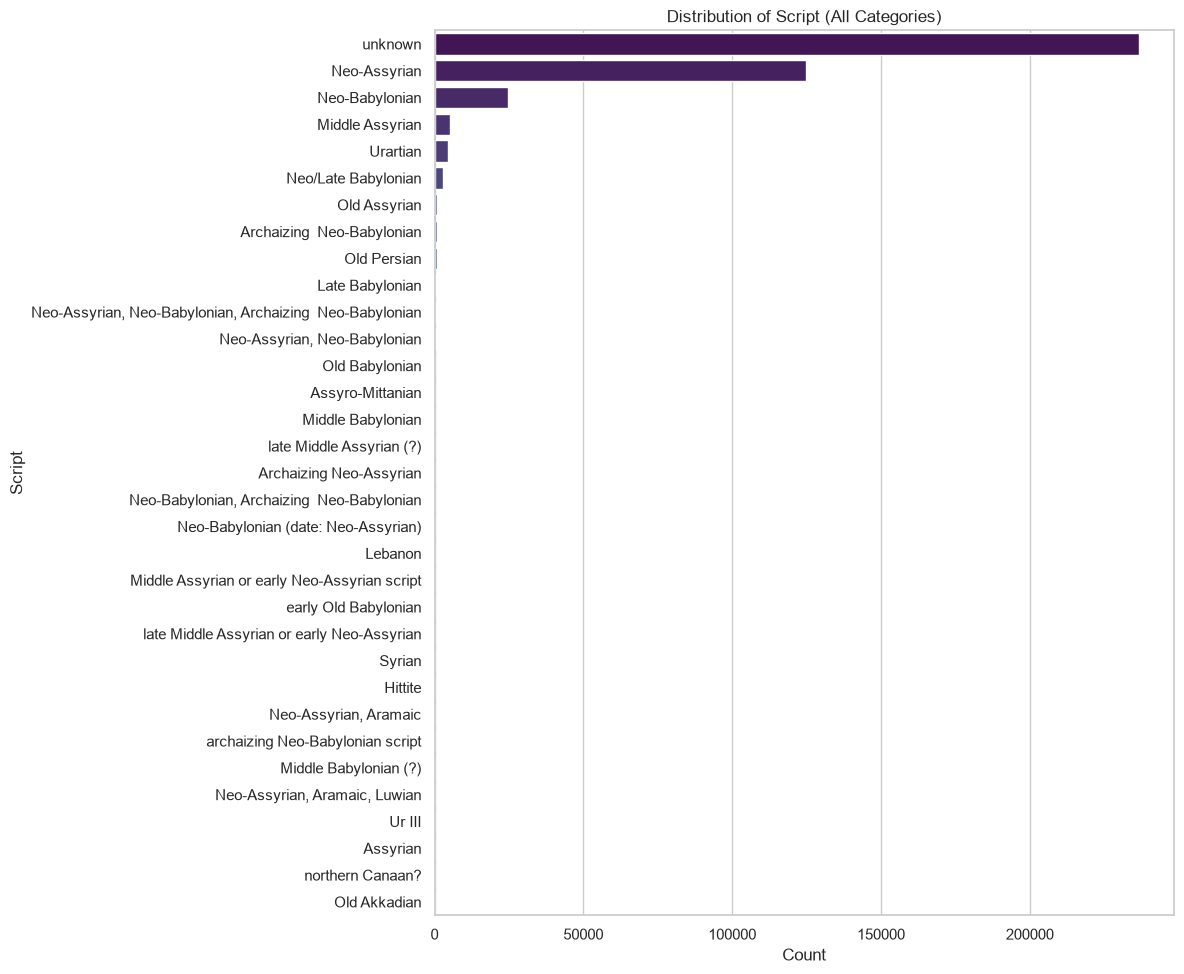


Top 10 values for ruler:
ruler
unknown                       226588
Ashurbanipal                   43747
Esarhaddon                     27661
Sargon II                      24991
Sennacherib                    15410
Esarhaddon or Ashurbanipal     11245
Nabonidus                       6318
uncertain                       5933
Nebuchadnezzar II               4911
Tiglath-pileser III             4347
Name: count, dtype: int64




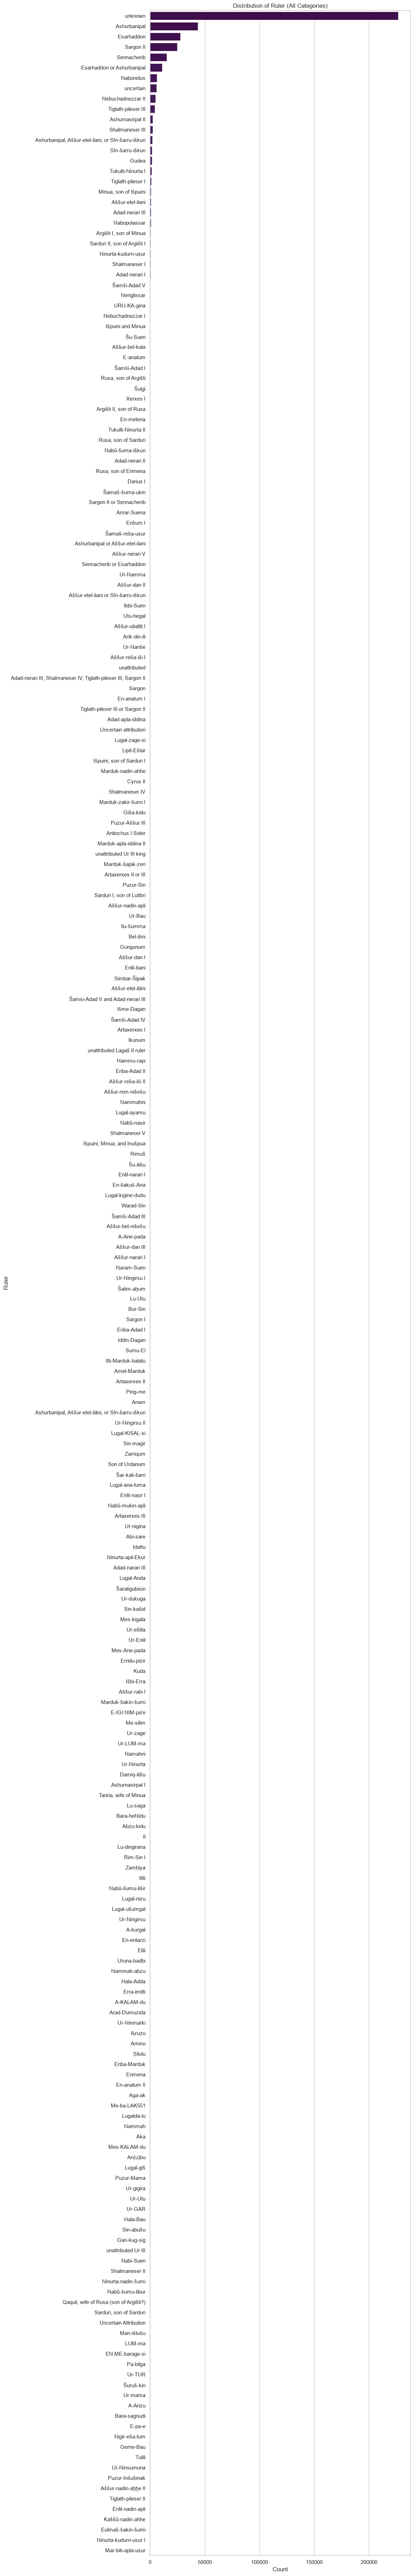

In [3]:
sns.set_theme(style='whitegrid')

for col in meta_cols:
    val_counts = df[col].value_counts()
    
    if len(val_counts) == 0:
        continue
        
    print(f'\n=========================================')
    print(f'Top 10 values for {col}:')
    print(f'=========================================')
    print(val_counts.head(10))
    print('\n')
    
    # Plot all categories
    plt.figure(figsize=(12, max(6, len(val_counts) * 0.3)))
    sns.barplot(y=val_counts.index, x=val_counts.values, hue=val_counts.index, legend=False, palette='viridis')
    plt.title(f'Distribution of {col.capitalize()} (All Categories)')
    plt.xlabel('Count')
    plt.ylabel(col.capitalize())
    plt.tight_layout()
    plt.show()